In [2]:
!nvidia-smi

Sun Apr  5 10:42:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 0. Kaggle settings

Before running:
1. Open **Notebook Settings**
2. Set **Accelerator = GPU**
3. Make sure the environment has **2 GPUs** available

This notebook will first verify the GPU count with `nvidia-smi`.

In [3]:
import os
import subprocess
from pathlib import Path

def run(cmd, check=True):
    print(f"$ {cmd}")
    result = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    print(result.stdout)
    if result.stderr.strip():
        print(result.stderr)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed: {cmd}")
    return result

run("nvidia-smi")

$ nvidia-smi
Sun Apr  5 10:42:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------------

CompletedProcess(args='nvidia-smi', returncode=0, stdout='Sun Apr  5 10:42:16 2026       \n+-----------------------------------------------------------------------------------------+\n| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |\n+-----------------------------------------+------------------------+----------------------+\n| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |\n| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |\n|                                         |                        |               MIG M. |\n|=========================================+========================+======================|\n|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |\n| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |\n|                                         |                        |    

## 1. Clone and build NCCL tests

If `nccl-tests` is already present, this cell will reuse it.

In [7]:
WORKDIR = Path("/kaggle/working")
NCCL_TESTS_DIR = WORKDIR / "nccl-tests"

if not NCCL_TESTS_DIR.exists():
    run(f"git clone https://github.com/NVIDIA/nccl-tests.git {NCCL_TESTS_DIR}")

os.chdir(NCCL_TESTS_DIR)
run("make MPI=0 CUDA_HOME=/usr/local/cuda -j")
run("ls build")

$ make MPI=0 CUDA_HOME=/usr/local/cuda -j
make -C src build BUILDDIR=/kaggle/working/nccl-tests/build
make[1]: Entering directory '/kaggle/working/nccl-tests/src'
Compiling /kaggle/working/nccl-tests/build/verifiable/verifiable.o
Compiling  all_reduce.cu                       > /kaggle/working/nccl-tests/build/all_reduce.o
Compiling  common.cu                           > /kaggle/working/nccl-tests/build/common.o
Compiling  util.cu                             > /kaggle/working/nccl-tests/build/util.o
Compiling  all_gather.cu                       > /kaggle/working/nccl-tests/build/all_gather.o
Compiling  broadcast.cu                        > /kaggle/working/nccl-tests/build/broadcast.o
Compiling  reduce_scatter.cu                   > /kaggle/working/nccl-tests/build/reduce_scatter.o
Compiling  reduce.cu                           > /kaggle/working/nccl-tests/build/reduce.o
Compiling  alltoall.cu                         > /kaggle/working/nccl-tests/build/alltoall.o
Compiling  scatter.cu  

CompletedProcess(args='ls build', returncode=0, stdout='all_gather.o\nall_gather_perf\nall_reduce.o\nall_reduce_perf\nalltoall.o\nalltoall_perf\nbroadcast.o\nbroadcast_perf\ncommon.o\ngather.o\ngather_perf\nhypercube.o\nhypercube_perf\nreduce.o\nreduce_perf\nreduce_scatter.o\nreduce_scatter_perf\nscatter.o\nscatter_perf\nsendrecv.o\nsendrecv_perf\ntimer.o\nutil.o\nverifiable\n', stderr='')

## 2. Define a reusable benchmark runner

We will run all three collectives with the same parameters:
- min size: 8 bytes
- max size: 256 MB
- factor: 2
- GPUs: 2
- warmup: 5
- iterations: 20

In [12]:
import os
import subprocess
from pathlib import Path

WORKDIR = Path("/kaggle/working")
NCCL_TESTS_DIR = WORKDIR / "nccl-tests"

LOG_DIR = WORKDIR / "nccl_logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

def run_nccl_test(exe, name, min_bytes="8", max_bytes="256M", factor=2, gpus=2, extra_args="-w 5 -n 20"):
    exe_candidates = [
        NCCL_TESTS_DIR / exe,
        NCCL_TESTS_DIR / "build" / exe,
    ]

    exe_path = None
    for p in exe_candidates:
        if p.exists():
            exe_path = p
            break

    if exe_path is None:
        raise FileNotFoundError(
            f"Cannot find {exe} in {NCCL_TESTS_DIR} or {NCCL_TESTS_DIR / 'build'}"
        )

    log_path = LOG_DIR / f"{name}.txt"

    cmd = f"{exe_path} -b {min_bytes} -e {max_bytes} -f {factor} -g {gpus} {extra_args}"

    print(f"\n===== Running: {name} =====")
    print(f"Executable => {exe_path}")
    print(f"Command => {cmd}")
    print(f"Log => {log_path}\n")

    full_cmd = f"{cmd} | tee {log_path}"
    result = subprocess.run(full_cmd, shell=True, text=True)

    if result.returncode != 0:
        raise RuntimeError(f"Run failed for {name}")

    return log_path

print("NCCL_TESTS_DIR:", NCCL_TESTS_DIR)
print("Log directory:", LOG_DIR)

NCCL_TESTS_DIR: /kaggle/working/nccl-tests
Log directory: /kaggle/working/nccl_logs


## 3. Run the three benchmarks

This is the core experiment for Day 2.

In [13]:
allreduce_log = run_nccl_test("all_reduce_perf", "allreduce_day2")
rs_log        = run_nccl_test("reduce_scatter_perf", "reducescatter_day2")
ag_log        = run_nccl_test("all_gather_perf", "allgather_day2")

print(allreduce_log)
print(rs_log)
print(ag_log)


===== Running: allreduce_day2 =====
Executable => /kaggle/working/nccl-tests/build/all_reduce_perf
Command => /kaggle/working/nccl-tests/build/all_reduce_perf -b 8 -e 256M -f 2 -g 2 -w 5 -n 20
Log => /kaggle/working/nccl_logs/allreduce_day2.txt

# nccl-tests version 2.18.2 nccl-headers=22501 nccl-library=22501
# Collective test starting: all_reduce_perf
# nThread 1 nGpus 2 minBytes 8 maxBytes 268435456 step: 2(factor) warmup iters: 5 iters: 20 agg iters: 1 validation: 1 graph: 0 unalign: 0
#
# Using devices
#  Rank  0 Group  0 Pid   1879 on f8695b32d5b3 device  0 [0000:00:04] Tesla T4
#  Rank  1 Group  0 Pid   1879 on f8695b32d5b3 device  1 [0000:00:05] Tesla T4
#
#                                                              out-of-place                       in-place          
#       size         count      type   redop    root     time   algbw   busbw  #wrong     time   algbw   busbw  #wrong 
#        (B)    (elements)                               (us)  (GB/s)  (GB/s)            

## 4. Parse NCCL test logs into DataFrames

We extract:
- `size_bytes`
- `size_mb`
- `time_us`
- `algbw_GBs`
- `busbw_GBs`

This parser is intentionally tolerant of small formatting differences across versions.

In [14]:
import re
import pandas as pd

def parse_nccl_log(log_path, test_name=None):
    log_path = Path(log_path)
    rows = []

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue

            if s.startswith("#") or s.startswith("Out of bounds") or s.startswith("nThread"):
                continue

            if not re.match(r"^\d+", s):
                continue

            parts = re.split(r"\s+", s)

            # Typical nccl-tests rows often end with:
            # ... time algbw busbw errors
            if len(parts) < 8:
                continue

            try:
                size = int(parts[0])
                time_us = float(parts[-4])
                algbw = float(parts[-3])
                busbw = float(parts[-2])

                rows.append({
                    "test": test_name or log_path.stem,
                    "size_bytes": size,
                    "size_mb": size / (1024 * 1024),
                    "time_us": time_us,
                    "algbw_GBs": algbw,
                    "busbw_GBs": busbw,
                })
            except Exception:
                continue

    return pd.DataFrame(rows)

df_ar = parse_nccl_log(allreduce_log, "allreduce")
df_rs = parse_nccl_log(rs_log, "reducescatter")
df_ag = parse_nccl_log(ag_log, "allgather")

df = pd.concat([df_ar, df_rs, df_ag], ignore_index=True)
print(df.shape)
df.head()

(78, 6)


,test,size_bytes,size_mb,time_us,algbw_GBs,busbw_GBs
0,allreduce,8,0.000008,12.52,0.00,0.00
1,allreduce,16,0.000015,13.72,0.00,0.00
2,allreduce,32,0.000031,12.75,0.00,0.00
3,allreduce,64,0.000061,12.95,0.00,0.00
4,allreduce,128,0.000122,13.92,0.01,0.01


## 5. Focus on large-message behavior

Small-message results are often dominated by launch overheads and protocol details.
For communication intuition, we care most about larger sizes.

In [15]:
df_big = df[df["size_mb"] >= 1].copy()
df_big = df_big.sort_values(["size_bytes", "test"]).reset_index(drop=True)

print("Large-message subset shape:", df_big.shape)
df_big.head(12)

Large-message subset shape: (27, 6)


,test,size_bytes,size_mb,time_us,algbw_GBs,busbw_GBs
0,allgather,1048576,1.0,186.94,5.61,2.80
1,allreduce,1048576,1.0,297.03,3.53,3.53
2,reducescatter,1048576,1.0,187.11,5.60,2.80
3,allgather,2097152,2.0,345.46,6.07,3.04
4,allreduce,2097152,2.0,556.66,3.77,3.77
5,reducescatter,2097152,2.0,341.86,6.13,3.07
6,allgather,4194304,4.0,680.58,6.16,3.08
7,allreduce,4194304,4.0,1088.25,3.85,3.85
8,reducescatter,4194304,4.0,671.56,6.25,3.12
9,allgather,8388608,8.0,1334.26,6.29,3.14


## 6. Create comparison tables

We build two pivot tables:
- time in microseconds
- bus bandwidth in GB/s

In [16]:
pivot_time = df_big.pivot_table(
    index="size_mb",
    columns="test",
    values="time_us"
).sort_index()

pivot_busbw = df_big.pivot_table(
    index="size_mb",
    columns="test",
    values="busbw_GBs"
).sort_index()

print("=== time (us) ===")
display(pivot_time.tail(10))

print("\n=== bus bandwidth (GB/s) ===")
display(pivot_busbw.tail(10))

=== time (us) ===


test,allgather,allreduce,reducescatter
size_mb,,,
1.0,186.94,297.03,187.11
2.0,345.46,556.66,341.86
4.0,680.58,1088.25,671.56
8.0,1334.26,2121.56,1328.48
16.0,2634.97,4231.72,2639.63
32.0,5232.37,8432.17,5191.20
64.0,10369.70,16839.90,10269.40
128.0,20714.80,33668.50,19925.50
256.0,40918.20,67290.60,36571.90



=== bus bandwidth (GB/s) ===


test,allgather,allreduce,reducescatter
size_mb,,,
1.0,2.80,3.53,2.80
2.0,3.04,3.77,3.07
4.0,3.08,3.85,3.12
8.0,3.14,3.95,3.16
16.0,3.18,3.96,3.18
32.0,3.21,3.98,3.23
64.0,3.24,3.99,3.27
128.0,3.24,3.99,3.37
256.0,3.28,3.99,3.67


## 7. Plot the trends

Expected large-message intuition on 2 GPUs:
- `ReduceScatter` should generally be lighter than `AllReduce`
- `AllGather` should generally be lighter than `AllReduce`
- `ReduceScatter` and `AllGather` should have roughly similar trends
- Their combined intuition should line up with **AllReduce ≈ RS + AG**

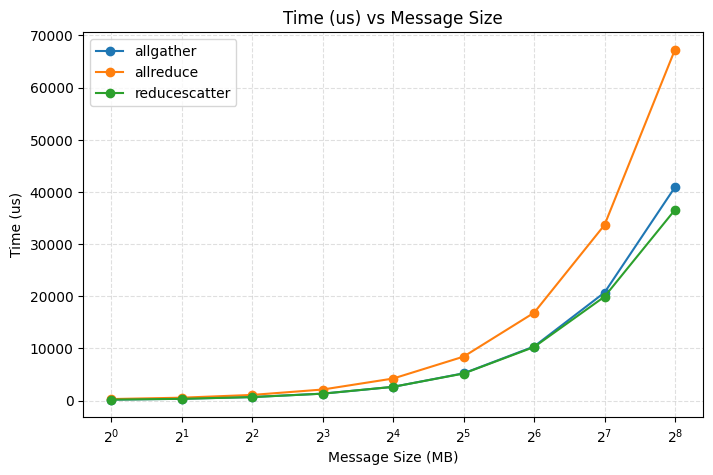

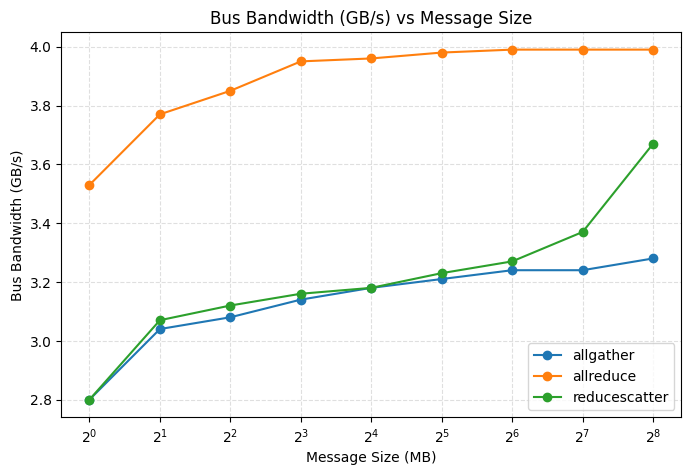

In [17]:
import matplotlib.pyplot as plt

for metric, ylabel in [("time_us", "Time (us)"), ("busbw_GBs", "Bus Bandwidth (GB/s)")]:
    plt.figure(figsize=(8, 5))
    for test_name, group in df_big.groupby("test"):
        g = group.sort_values("size_mb")
        plt.plot(g["size_mb"], g[metric], marker="o", label=test_name)
    plt.xscale("log", base=2)
    plt.xlabel("Message Size (MB)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs Message Size")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend()
    plt.show()

## 8. Compare RS + AG against AllReduce directly

This is not a perfect apples-to-apples API comparison because the exact input/output semantics differ,
but it is still a useful **intuition check**.

In [18]:
merged = pivot_time.copy()
if {"reducescatter", "allgather", "allreduce"}.issubset(set(merged.columns)):
    merged["rs_plus_ag_us"] = merged["reducescatter"] + merged["allgather"]
    merged["ratio_(rs+ag)/allreduce"] = merged["rs_plus_ag_us"] / merged["allreduce"]
    display(merged[["allreduce", "reducescatter", "allgather", "rs_plus_ag_us", "ratio_(rs+ag)/allreduce"]].tail(10))
else:
    print("Required columns missing; check the parsed table.")

test,allreduce,reducescatter,allgather,rs_plus_ag_us,ratio_(rs+ag)/allreduce
size_mb,,,,,
1.0,297.03,187.11,186.94,374.05,1.259300
2.0,556.66,341.86,345.46,687.32,1.234721
4.0,1088.25,671.56,680.58,1352.14,1.242490
8.0,2121.56,1328.48,1334.26,2662.74,1.255086
16.0,4231.72,2639.63,2634.97,5274.60,1.246444
32.0,8432.17,5191.20,5232.37,10423.57,1.236167
64.0,16839.90,10269.40,10369.70,20639.10,1.225607
128.0,33668.50,19925.50,20714.80,40640.30,1.207072
256.0,67290.60,36571.90,40918.20,77490.10,1.151574


## 9. Auto-generate the conceptual comparison table

This is the table you can directly reuse in your notes/report.

In [19]:
concept_df = pd.DataFrame([
    {
        "collective": "AllReduce",
        "input_shape": "Each GPU starts with a full tensor",
        "output_shape": "Each GPU gets the full reduced tensor",
        "what_each_gpu_keeps": "Full result",
        "ideal_comm_scale": "2(n-1)/n",
        "2_gpu_case": "1.0",
        "training_intuition": "DDP-style full gradient synchronization",
    },
    {
        "collective": "ReduceScatter",
        "input_shape": "Each GPU starts with a full tensor",
        "output_shape": "Each GPU gets one reduced shard",
        "what_each_gpu_keeps": "Only its own shard",
        "ideal_comm_scale": "(n-1)/n",
        "2_gpu_case": "0.5",
        "training_intuition": "Backward-time sharded gradient aggregation",
    },
    {
        "collective": "AllGather",
        "input_shape": "Each GPU starts with one shard",
        "output_shape": "Each GPU gets the reconstructed full tensor",
        "what_each_gpu_keeps": "Full tensor",
        "ideal_comm_scale": "(n-1)/n",
        "2_gpu_case": "0.5",
        "training_intuition": "Forward-time temporary parameter reconstruction",
    },
])

concept_df

,collective,input_shape,output_shape,what_each_gpu_keeps,ideal_comm_scale,2_gpu_case,training_intuition
0,AllReduce,Each GPU starts with a full tensor,Each GPU gets the full reduced tensor,Full result,2(n-1)/n,1.0,DDP-style full gradient synchronization
1,ReduceScatter,Each GPU starts with a full tensor,Each GPU gets one reduced shard,Only its own shard,(n-1)/n,0.5,Backward-time sharded gradient aggregation
2,AllGather,Each GPU starts with one shard,Each GPU gets the reconstructed full tensor,Full tensor,(n-1)/n,0.5,Forward-time temporary parameter reconstruction


## 10. Add the Day 2 explanation diagram (ASCII version)

You can reuse this in your report if you do not want to draw a figure manually.

In [21]:
ascii_diagram = r"""
ReduceScatter on 2 GPUs
-----------------------
Before:
GPU0: [a0 b0]
GPU1: [a1 b1]

After ReduceScatter(sum):
GPU0: [a0+a1]
GPU1: [b0+b1]


AllGather on 2 GPUs
-------------------
Before:
GPU0: [p0]
GPU1: [p1]

After AllGather:
GPU0: [p0 p1]
GPU1: [p0 p1]


AllReduce = ReduceScatter + AllGather
-------------------------------------
Start:
GPU0: [a0 b0]
GPU1: [a1 b1]

Step 1: ReduceScatter
GPU0: [a0+a1]
GPU1: [b0+b1]

Step 2: AllGather
GPU0: [a0+a1, b0+b1]
GPU1: [a0+a1, b0+b1]
"""
print(ascii_diagram)


ReduceScatter on 2 GPUs
-----------------------
Before:
GPU0: [a0 b0]
GPU1: [a1 b1]

After ReduceScatter(sum):
GPU0: [a0+a1]
GPU1: [b0+b1]


AllGather on 2 GPUs
-------------------
Before:
GPU0: [p0]
GPU1: [p1]

After AllGather:
GPU0: [p0 p1]
GPU1: [p0 p1]


AllReduce = ReduceScatter + AllGather
-------------------------------------
Start:
GPU0: [a0 b0]
GPU1: [a1 b1]

Step 1: ReduceScatter
GPU0: [a0+a1]
GPU1: [b0+b1]

Step 2: AllGather
GPU0: [a0+a1, b0+b1]
GPU1: [a0+a1, b0+b1]



## 11. Final notes you can directly reuse

### Key conclusion
For 2 GPUs, the ideal communication scaling suggests:
- AllReduce: `1.0`
- ReduceScatter: `0.5`
- AllGather: `0.5`

This matches the intuition that:

**AllReduce ≈ ReduceScatter + AllGather**

### Why this matters for sharded training
- **Backward** often wants reduced gradients, but only the local shard must remain on each GPU → **ReduceScatter**
- **Forward** often needs full parameters only temporarily, reconstructed from shards → **AllGather**

That is why staged communication is a natural fit for **FSDP / ZeRO**-style training.

## 12. Optional: save parsed tables to CSV

Useful if you want to attach results to your notes or compare with later runs.

In [22]:
df.to_csv(WORKDIR / "day2_all_collectives_raw.csv", index=False)
pivot_time.to_csv(WORKDIR / "day2_pivot_time_us.csv")
pivot_busbw.to_csv(WORKDIR / "day2_pivot_busbw.csv")
concept_df.to_csv(WORKDIR / "day2_concept_table.csv", index=False)

print("Saved:")
print(WORKDIR / "day2_all_collectives_raw.csv")
print(WORKDIR / "day2_pivot_time_us.csv")
print(WORKDIR / "day2_pivot_busbw.csv")
print(WORKDIR / "day2_concept_table.csv")

Saved:
/kaggle/working/day2_all_collectives_raw.csv
/kaggle/working/day2_pivot_time_us.csv
/kaggle/working/day2_pivot_busbw.csv
/kaggle/working/day2_concept_table.csv
